# Sequence model comparison on real squat-quality data

This notebook extends the capstone pipeline with **multiple sequence models** trained on the **real squat videos and error labels in this repository**.

Models compared here:
- **BiLSTM**
- **Temporal CNN**
- **Transformer Encoder**
- **Transformer + bottleneck adapters**

Important scope note:
- The repository still contains only one exercise class (`squat`), so this benchmark is for **squat quality/error classification**, not multi-exercise recognition.
- A bottleneck-adapter transformer is used as the parameter-efficient transformer variant because this project uses a **small custom sequence encoder** rather than a large pretrained backbone where DoRA is usually more appropriate.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

from scripts.task3_sequence_model_comparison import run_model_comparison

outputs = run_model_comparison(
    sample_per_class=40,
    sequence_length=30,
    epochs=35,
    batch_size=16,
    learning_rate=1e-3,
    confidence_threshold=0.5,
    seed=42,
    force_rebuild_cache=False,
)

project_root = Path.cwd()
reports_dir = project_root / 'reports'
figures_dir = project_root / 'figures'

subset = outputs['subset_with_splits']
summary_df = outputs['summary_df']
with (reports_dir / 'task3_benchmark_notes.json').open('r', encoding='utf-8') as handle:
    notes = json.load(handle)

print('Balanced subset videos:', len(subset))
print('Best model:', summary_df.iloc[0]['model_name'])

Training BiLSTM


Training Temporal CNN


Training Transformer Encoder


/workspace/scripts/task3_sequence_model_comparison.py:406: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)


Training Transformer + Adapters


/workspace/scripts/task3_sequence_model_comparison.py:646: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()


Balanced subset videos: 160
Best model: Temporal CNN


## Benchmark design

To keep the comparison fair while staying grounded in the repository's real data:
- the benchmark uses **all 40 `knees_inward` videos** and samples **40 videos from each other label**, creating a balanced 160-video subset;
- each video is represented by **30 sampled frames**;
- each frame is converted to **normalized BlazePose keypoints plus biomechanical angle features**;
- train / validation / test splits are created by a reproducible stratified split over this balanced subset.

This gives a much fairer architecture comparison than using the original highly imbalanced split, where the rarest class has only 3 test examples.

In [2]:
display(Markdown('### Benchmark notes'))
display(pd.DataFrame(notes.items(), columns=['item', 'value']))

display(Markdown('### Balanced subset distribution by benchmark split and label'))
display(subset.groupby(['benchmark_split', 'quality_label']).size().unstack(fill_value=0))

display(Markdown('### Sampled videos (first rows)'))
display(subset[['video_id', 'split', 'benchmark_split', 'quality_label']].head(12))

### Benchmark notes

,item,value
0,task_scope,4-class squat-quality classification on a bala...
1,why_balanced_subset,"The rarest label, knees_inward, has only 40 vi..."
2,sequence_length,30
3,feature_dimension,44
4,selected_pose_backbone,MediaPipe BlazePose
5,transformer_adapter_note,A bottleneck adapter transformer is used inste...


### Balanced subset distribution by benchmark split and label

quality_label,knees_forward,knees_inward,multiple_annotated_errors,no_annotated_error
benchmark_split,,,,
test,6,6,6,6
train,28,28,28,28
val,6,6,6,6


### Sampled videos (first rows)

,video_id,split,benchmark_split,quality_label
0,36354_2,train,test,knees_forward
1,37915_1,train,test,knees_forward
2,46777_1,train,test,knees_forward
3,48007_1,train,test,knees_forward
4,49385_1,train,test,knees_forward
5,50309_4,train,test,knees_forward
6,33387_1,train,test,knees_inward
7,46502_1,train,test,knees_inward
8,47614_1,test,test,knees_inward
9,47790_1,val,test,knees_inward


## Model comparison results

The two key metrics here are:
- **test macro-F1**, which matters most because the classes are balanced in this benchmark;
- **test accuracy**, as a secondary summary metric.

A recommended model is selected from the measured results, not by assumption.

In [3]:
display(summary_df)

best_row = summary_df.iloc[0]
display(Markdown(
    f"**Recommended model for this benchmark:** {best_row['model_name']}  "
    f"(test macro-F1 = {best_row['test_macro_f1']:.3f}, test accuracy = {best_row['test_accuracy']:.3f})"
))

,model_name,parameter_count,best_epoch,val_macro_f1,test_accuracy,test_macro_f1,recommended_for_project
0,Temporal CNN,107780,2,0.487500,0.458333,0.437500,True
1,BiLSTM,164420,1,0.369444,0.416667,0.407307,False
2,Transformer + Adapters,78884,3,0.483852,0.375000,0.382576,False
3,Transformer Encoder,74372,16,0.416550,0.333333,0.296930,False


**Recommended model for this benchmark:** Temporal CNN  (test macro-F1 = 0.438, test accuracy = 0.458)

### Metric summary chart

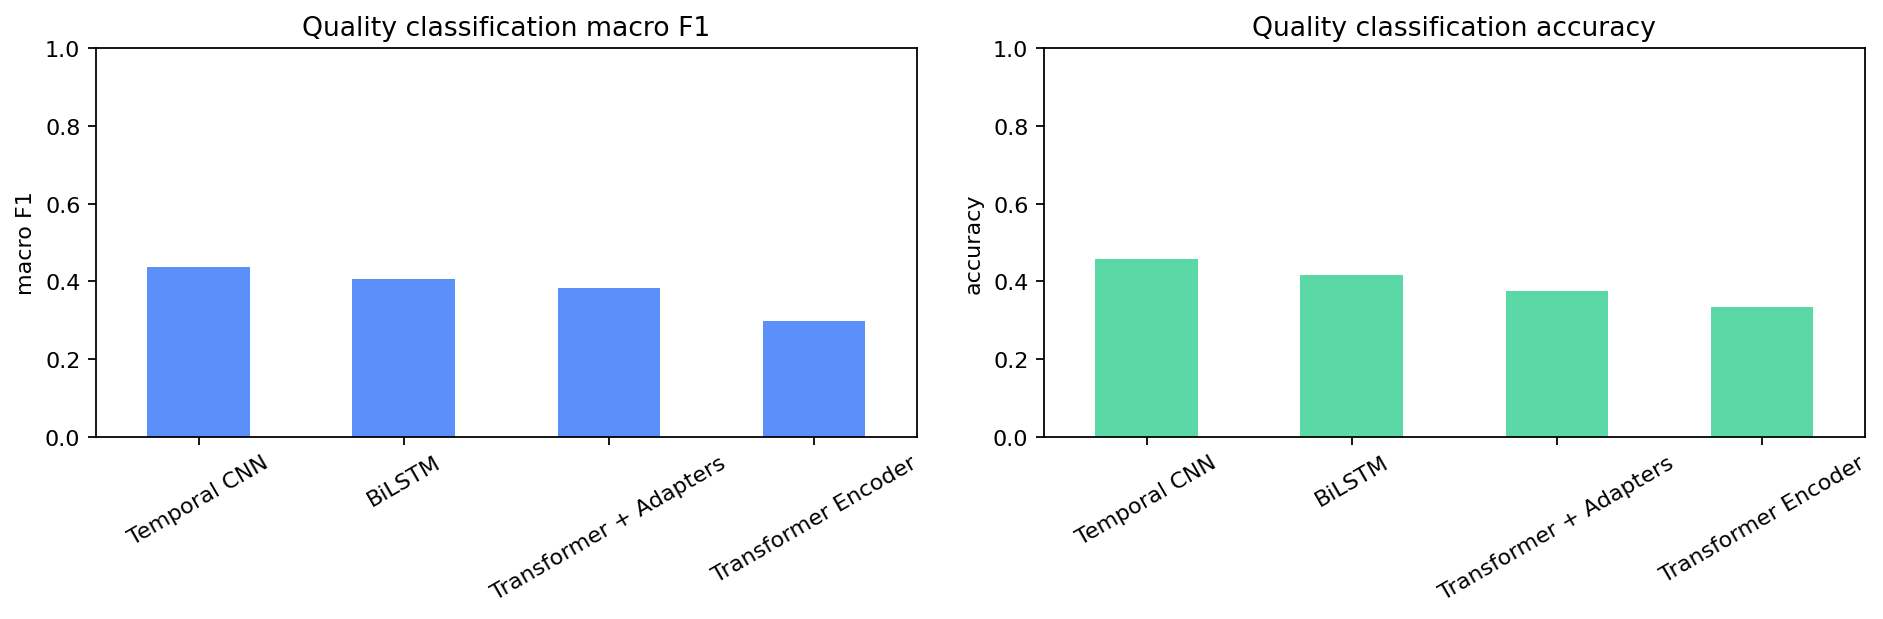

### Confusion matrices

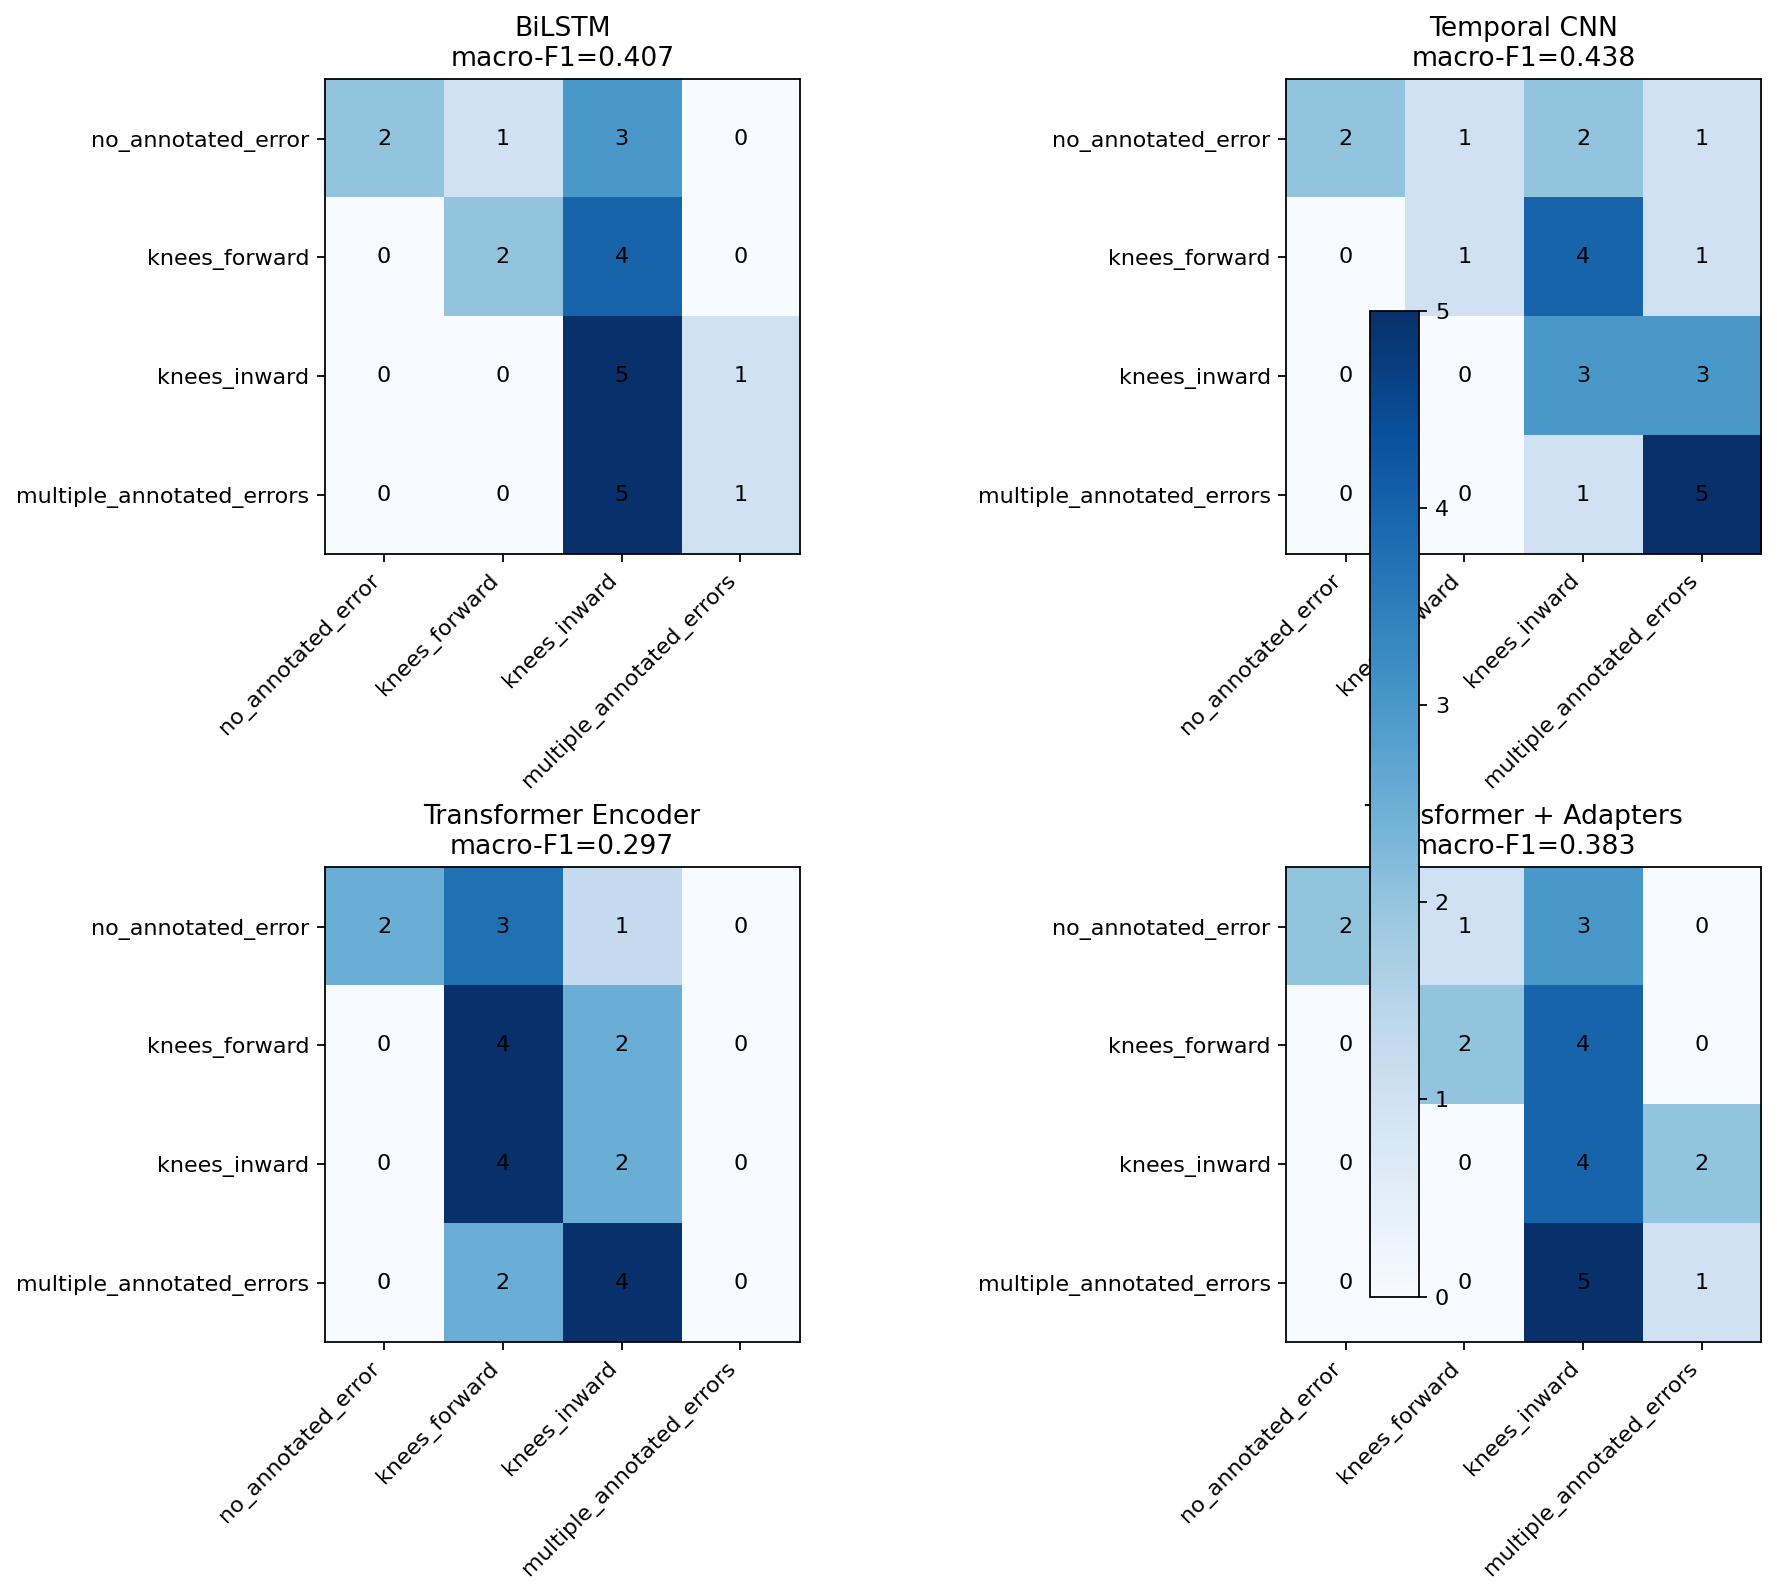

In [4]:
display(Markdown('### Metric summary chart'))
display(Image(filename=str(figures_dir / 'task3_model_metrics.png')))

display(Markdown('### Confusion matrices'))
display(Image(filename=str(figures_dir / 'task3_confusion_matrices.png')))

## Outcome

This notebook gives you the broader sequence-model comparison you asked for:
- **LSTM** baseline,
- **CNN** baseline,
- **Transformer** baseline,
- **Transformer + adapters** as the suitable parameter-efficient alternative for this project.

Because the repo currently has only squat videos, this is the strongest comparison we can make today while staying faithful to the project’s real data.